In [23]:
!pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ----- ---------------------------------- 6.6/48.9 MB 37.5 MB/s eta 0:00:02
   ------------ --------------------------- 15.2/48.9 MB 38.7 MB/s eta 0:00:01
   ------------------- -------------------- 23.9/48.9 MB 39.2 MB/s eta 0:00:01
   -------------------------- ------------- 32.2/48.9 MB 39.5 MB/s eta 0:00:01
   --------------------------------- ------ 40.6/48.9 MB 39.7 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 39.8 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 34.0 MB/s  0:00:01


In [24]:
# I import all the libraries I need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# I load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print(df.head())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

In [25]:
# I check data types
print(df.dtypes)

# I convert TotalCharges to numeric
# because it is stored as text
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'], errors='coerce')

# I drop rows with missing values
df = df.dropna()

# I drop customerID as it adds no value
df = df.drop('customerID', axis=1)

# I convert SeniorCitizen to Yes No
# to match other columns
df['SeniorCitizen'] = df['SeniorCitizen'].map(
    {0: 'No', 1: 'Yes'})

print("Shape after cleaning:", df.shape)
print(df.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object
Shape after cleaning: (7032, 20)
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
S

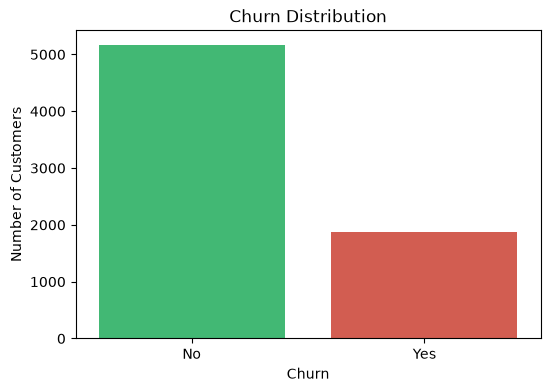

Churn Rate:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


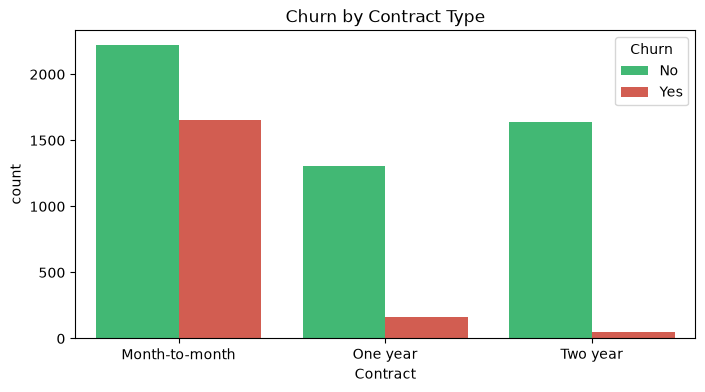

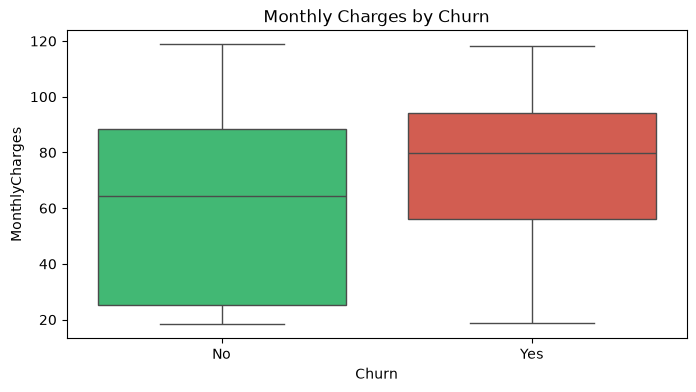

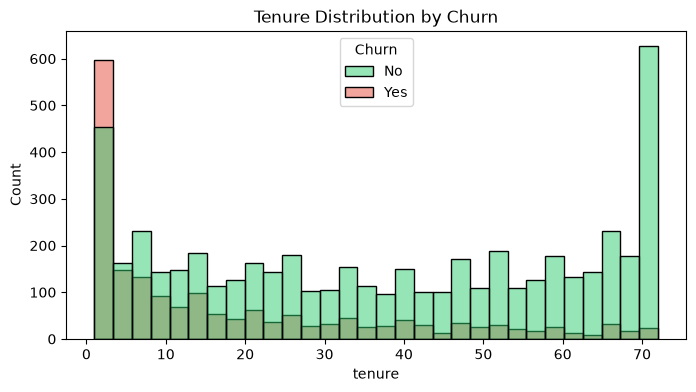

In [26]:
# I visualise the churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, 
              palette=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

# I calculate churn rate
churn_rate = df['Churn'].value_counts(
    normalize=True) * 100
print("Churn Rate:")
print(churn_rate)

# I visualise churn by contract type
plt.figure(figsize=(8, 4))
sns.countplot(x='Contract', hue='Churn', 
              data=df, 
              palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Contract Type')
plt.show()

# I visualise churn by monthly charges
plt.figure(figsize=(8, 4))
sns.boxplot(x='Churn', y='MonthlyCharges', 
            data=df, 
            palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges by Churn')
plt.show()

# I visualise churn by tenure
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='tenure', 
             hue='Churn', bins=30,
             palette=['#2ecc71', '#e74c3c'])
plt.title('Tenure Distribution by Churn')
plt.show()

In [27]:
# I create a copy of the dataframe
df_encoded = df.copy()

# I encode the target variable
df_encoded['Churn'] = df_encoded[
    'Churn'].map({'Yes': 1, 'No': 0})

# I identify categorical columns
cat_cols = df_encoded.select_dtypes(
    include='object').columns
print("Categorical columns:", list(cat_cols))

# I encode all categorical columns
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(
        df_encoded[col])

print("\nData types after encoding:")
print(df_encoded.dtypes)
print("\nFirst 5 rows after encoding:")
print(df_encoded.head())

Categorical columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Data types after encoding:
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

First 5 rows after encoding:
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0          

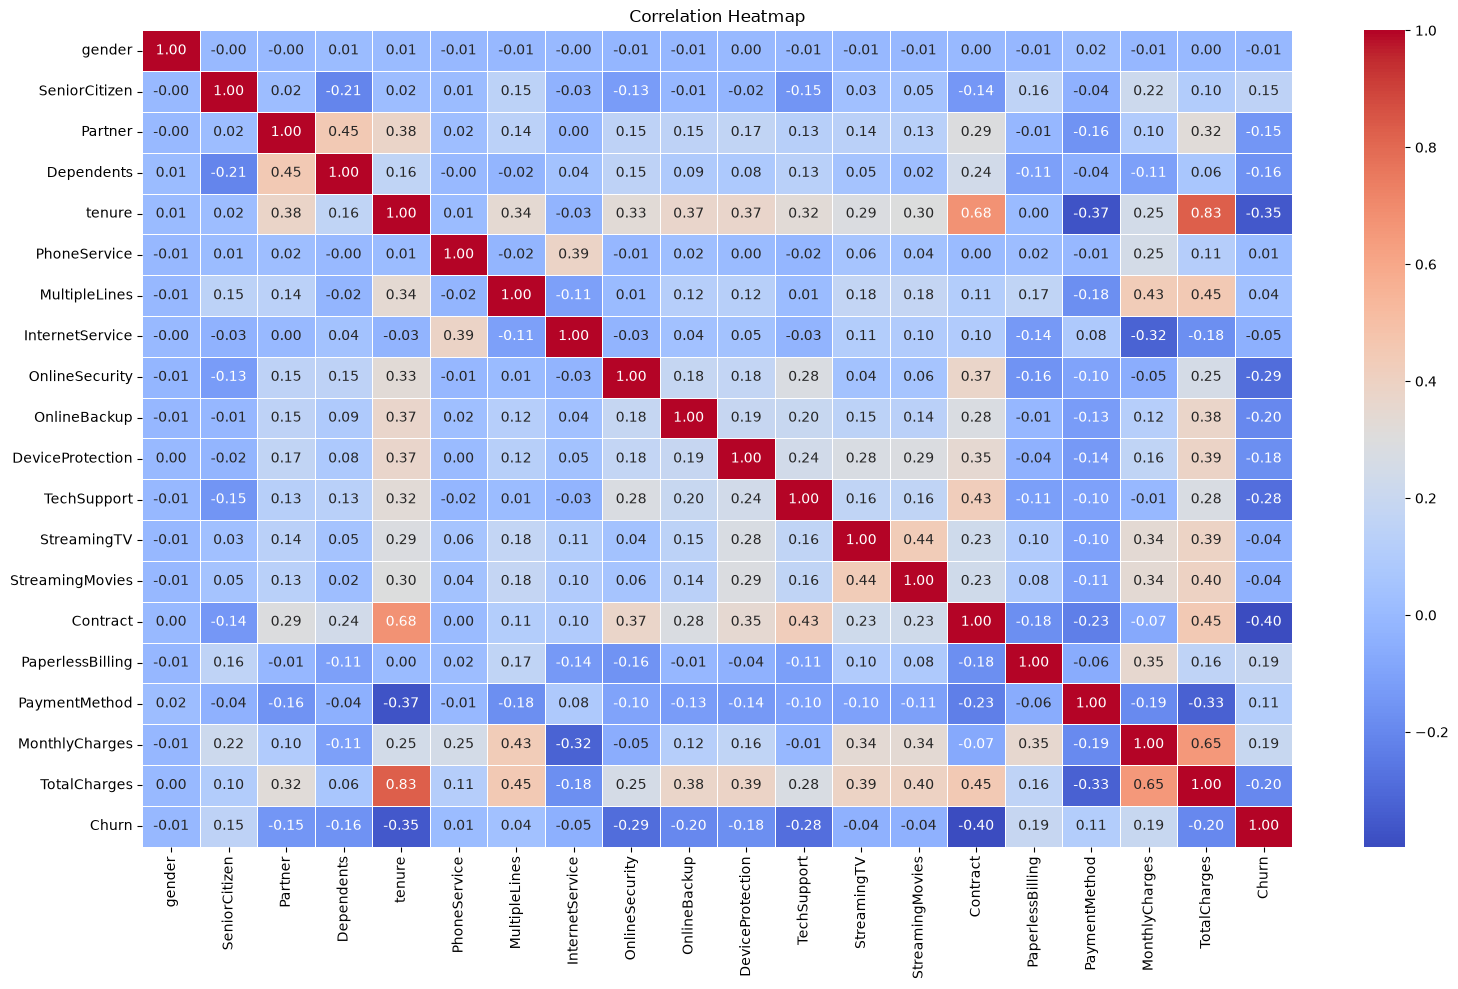

In [28]:
# I visualise correlations between features
plt.figure(figsize=(16, 10))
sns.heatmap(df_encoded.corr(), 
            annot=True, fmt='.2f',
            cmap='coolwarm', 
            linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [29]:
# I separate features and target variable
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# I split into training and test sets
# 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, 
    random_state=42, stratify=y)

print("\nTraining set size:", X_train.shape)
print("Test set size:", X_test.shape)

Features shape: (7032, 19)
Target shape: (7032,)

Training set size: (5625, 19)
Test set size: (1407, 19)


In [30]:
# I define the three models I want to train
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss', 
        random_state=42)
}

# I train and evaluate each model
results = {}
for name, model in models.items():
    # I train the model
    model.fit(X_train, y_train)
    
    # I make predictions on test set
    y_pred = model.predict(X_test)
    
    # I calculate all metrics
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    }
    
    print(f"\n{name}:")
    print(f"Accuracy:  {results[name]['Accuracy']:.2%}")
    print(f"Precision: {results[name]['Precision']:.2%}")
    print(f"Recall:    {results[name]['Recall']:.2%}")
    print(f"F1 Score:  {results[name]['F1 Score']:.2%}")


Logistic Regression:
Accuracy:  79.60%
Precision: 62.83%
Recall:    56.95%
F1 Score:  59.75%

Random Forest:
Accuracy:  78.32%
Precision: 61.77%
Recall:    48.40%
F1 Score:  54.27%

XGBoost:
Accuracy:  77.33%
Precision: 58.11%
Recall:    52.67%
F1 Score:  55.26%


                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.796020   0.628319  0.569519  0.597475
Random Forest        0.783227   0.617747  0.483957  0.542729
XGBoost              0.773276   0.581121  0.526738  0.552595


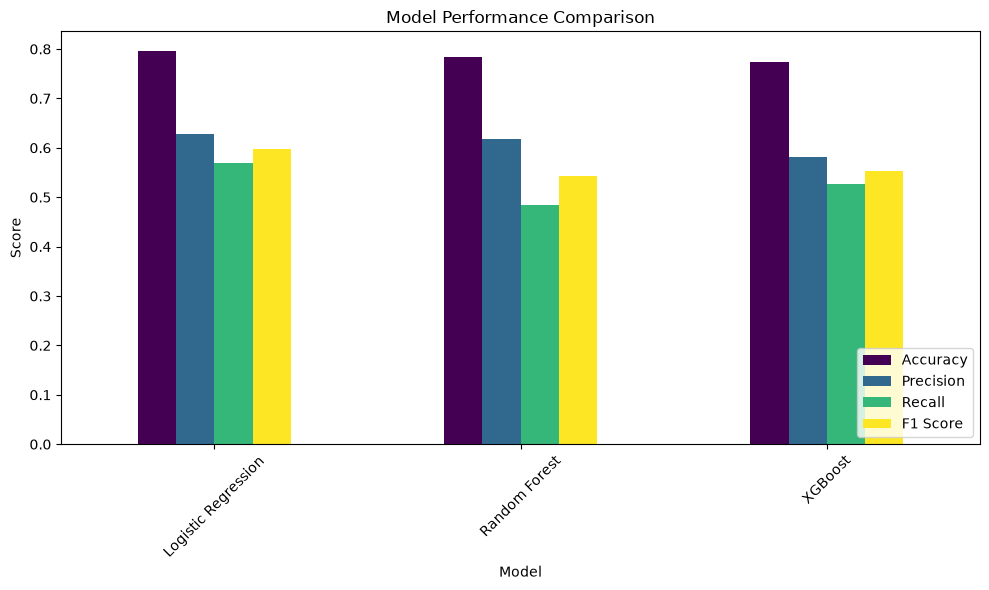

In [31]:
# I create a comparison dataframe
results_df = pd.DataFrame(results).T
print(results_df)

# I visualise the comparison
results_df.plot(kind='bar', figsize=(10, 6),
                colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.58      0.53      0.55       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.70      1407
weighted avg       0.77      0.77      0.77      1407



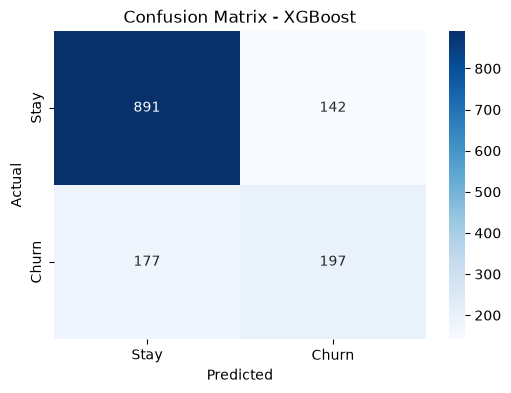

In [32]:
# I select XGBoost as the best model
best_model = models['XGBoost']
y_pred_best = best_model.predict(X_test)

# I print the full classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_best))

# I visualise the confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Stay', 'Churn'],
            yticklabels=['Stay', 'Churn'])
plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Top 10 Most Important Features:
             Feature  Importance
14          Contract    0.400549
7    InternetService    0.144876
8     OnlineSecurity    0.076813
11       TechSupport    0.051585
4             tenure    0.028362
5       PhoneService    0.028178
6      MultipleLines    0.024725
9       OnlineBackup    0.024407
15  PaperlessBilling    0.023805
10  DeviceProtection    0.022473


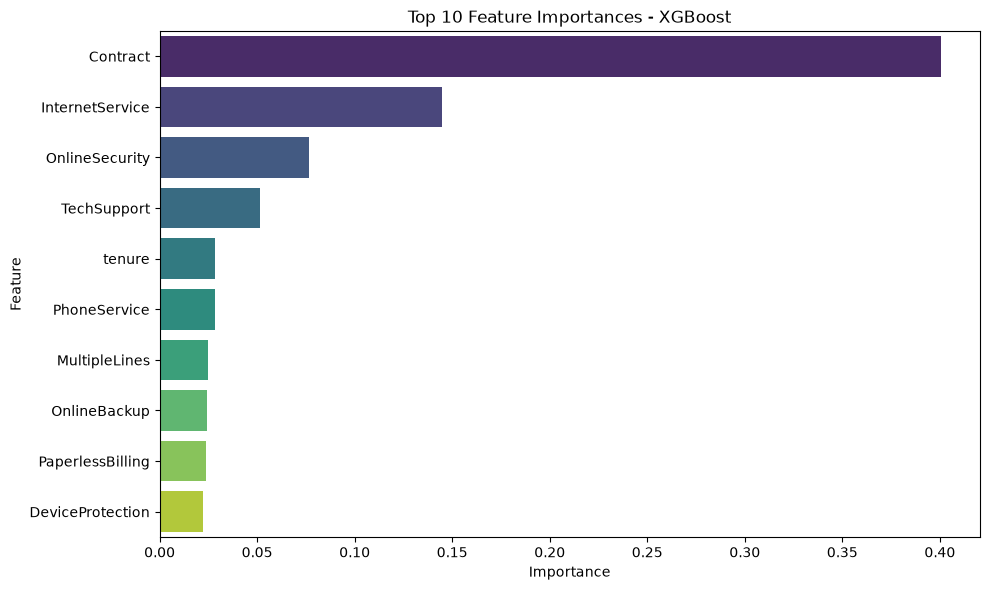

In [33]:
# I get feature importance from XGBoost
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

# I visualise feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance.head(10),
            palette='viridis')
plt.title('Top 10 Feature Importances - XGBoost')
plt.tight_layout()
plt.show()

In [34]:
# I save the best model to use in the app
import pickle

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# I also save the feature column names
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)

print("Model saved successfully!")

Model saved successfully!


In [36]:
# I write the Streamlit app to a file
app_code = '''
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# I load the saved model and feature columns
with open("churn_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("feature_columns.pkl", "rb") as f:
    feature_columns = pickle.load(f)

st.title("Customer Churn Prediction App")
st.write("Enter customer details to predict whether they will churn.")

# I create input fields for the user
gender = st.selectbox("Gender", ["Male", "Female"])
senior_citizen = st.selectbox("Senior Citizen", ["No", "Yes"])
partner = st.selectbox("Has Partner", ["Yes", "No"])
dependents = st.selectbox("Has Dependents", ["Yes", "No"])
tenure = st.slider("Tenure (months)", 0, 72, 12)
phone_service = st.selectbox("Phone Service", ["Yes", "No"])
multiple_lines = st.selectbox("Multiple Lines", ["Yes", "No", "No phone service"])
internet_service = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
online_security = st.selectbox("Online Security", ["Yes", "No", "No internet service"])
online_backup = st.selectbox("Online Backup", ["Yes", "No", "No internet service"])
device_protection = st.selectbox("Device Protection", ["Yes", "No", "No internet service"])
tech_support = st.selectbox("Tech Support", ["Yes", "No", "No internet service"])
streaming_tv = st.selectbox("Streaming TV", ["Yes", "No", "No internet service"])
streaming_movies = st.selectbox("Streaming Movies", ["Yes", "No", "No internet service"])
contract = st.selectbox("Contract Type", ["Month-to-month", "One year", "Two year"])
paperless_billing = st.selectbox("Paperless Billing", ["Yes", "No"])
payment_method = st.selectbox("Payment Method", [
    "Electronic check", "Mailed check",
    "Bank transfer (automatic)", "Credit card (automatic)"])
monthly_charges = st.number_input("Monthly Charges ($)", 0.0, 200.0, 50.0)
total_charges = st.number_input("Total Charges ($)", 0.0, 10000.0, 500.0)

# I create a prediction button
if st.button("Predict Churn"):
    
    # I build the input dataframe
    input_data = pd.DataFrame([{
        "gender": gender,
        "SeniorCitizen": senior_citizen,
        "Partner": partner,
        "Dependents": dependents,
        "tenure": tenure,
        "PhoneService": phone_service,
        "MultipleLines": multiple_lines,
        "InternetService": internet_service,
        "OnlineSecurity": online_security,
        "OnlineBackup": online_backup,
        "DeviceProtection": device_protection,
        "TechSupport": tech_support,
        "StreamingTV": streaming_tv,
        "StreamingMovies": streaming_movies,
        "Contract": contract,
        "PaperlessBilling": paperless_billing,
        "PaymentMethod": payment_method,
        "MonthlyCharges": monthly_charges,
        "TotalCharges": total_charges
    }])

    # I encode the input data the same way as training
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    for col in input_data.select_dtypes(include="object").columns:
        input_data[col] = le.fit_transform(input_data[col])

    # I make the prediction
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    # I display the result
    if prediction == 1:
        st.error(f"This customer is likely to CHURN! Probability: {probability:.1%}")
    else:
        st.success(f"This customer is likely to STAY! Probability of churn: {probability:.1%}")
'''

# I write the app code to a file
with open('app.py', 'w') as f:
    f.write(app_code)

print("Streamlit app created successfully!")
print("File saved as app.py")

Streamlit app created successfully!
File saved as app.py


In [37]:
# I print instructions to run the app
print("To run your Streamlit app:")
print("1. Open your terminal")
print("2. Navigate to your project folder")
print("3. Type: streamlit run app.py")
print("4. Your app will open in the browser!")

To run your Streamlit app:
1. Open your terminal
2. Navigate to your project folder
3. Type: streamlit run app.py
4. Your app will open in the browser!


In [1]:
import os
print(os.getcwd())

C:\Users\joshu
